In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3687, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51
1,flat,signature global solera,sector 107,0.28,5680.0,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45
2,flat,hcbs sports ville,sohna road,0.29,5588.0,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44
3,flat,orchid petals,sector 49,2.55,12319.0,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49
4,house,signature global city,sector 37d,1.27,8089.0,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89


In [6]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [7]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89


luxury score

<Axes: xlabel='luxury_score'>

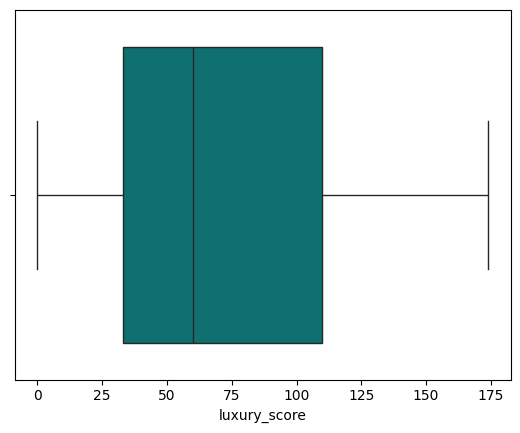

In [10]:
sns.boxplot(x=df['luxury_score'],color='teal')

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51,Medium
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45,Low
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44,Low
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49,Low
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89,Medium


floorNum

<Axes: xlabel='floorNum'>

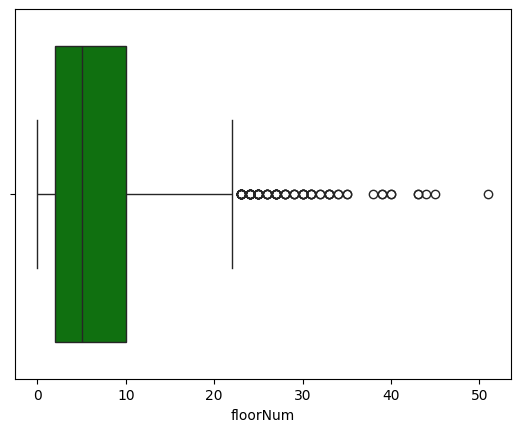

In [16]:
sns.boxplot(x=df['floorNum'],color='green')

In [17]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [18]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 81,4.35,4,4,3,2.0,Relatively New,5480.0,0,1,1,0,0,0,51,Medium,Low Floor
1,flat,sector 107,0.28,2,2,2,6.0,Relatively New,543.0,0,0,0,0,0,0,45,Low,Mid Floor
2,flat,sohna road,0.29,2,2,1,4.0,Relatively New,577.0,0,0,0,0,0,0,44,Low,Mid Floor
3,flat,sector 49,2.55,3,4,3,8.0,Relatively New,2060.0,1,0,0,0,0,1,49,Low,Mid Floor
4,house,sector 37d,1.27,3,3,3,4.0,Under Construction,1570.0,0,0,0,1,0,0,89,Medium,Mid Floor


In [20]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [21]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 81,4.35,4,4,3,Relatively New,5480.0,0,1,1,0,0,0,Medium,Low Floor
1,flat,sector 107,0.28,2,2,2,Relatively New,543.0,0,0,0,0,0,0,Low,Mid Floor
2,flat,sohna road,0.29,2,2,1,Relatively New,577.0,0,0,0,0,0,0,Low,Mid Floor
3,flat,sector 49,2.55,3,4,3,Relatively New,2060.0,1,0,0,0,0,1,Low,Mid Floor
4,house,sector 37d,1.27,3,3,3,Under Construction,1570.0,0,0,0,1,0,0,Medium,Mid Floor


In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [23]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,1,0,0,0,2.0,1.0
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,0,0,0,1.0,2.0
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,0,0,0,1.0,2.0
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,0,0,0,1,1.0,2.0
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,1,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,0,0,0,1.0,2.0
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,0,0,0,1.0,0.0
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,0,0,0,2.0,2.0
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,0,1,1,2,2.0,2.0


In [24]:
y_label

,price
0,4.35
1,0.28
2,0.29
3,2.55
4,1.27
...,...
3682,5.51
3683,1.23
3684,0.87
3685,1.65


Technique 1 - Correlation Analysis

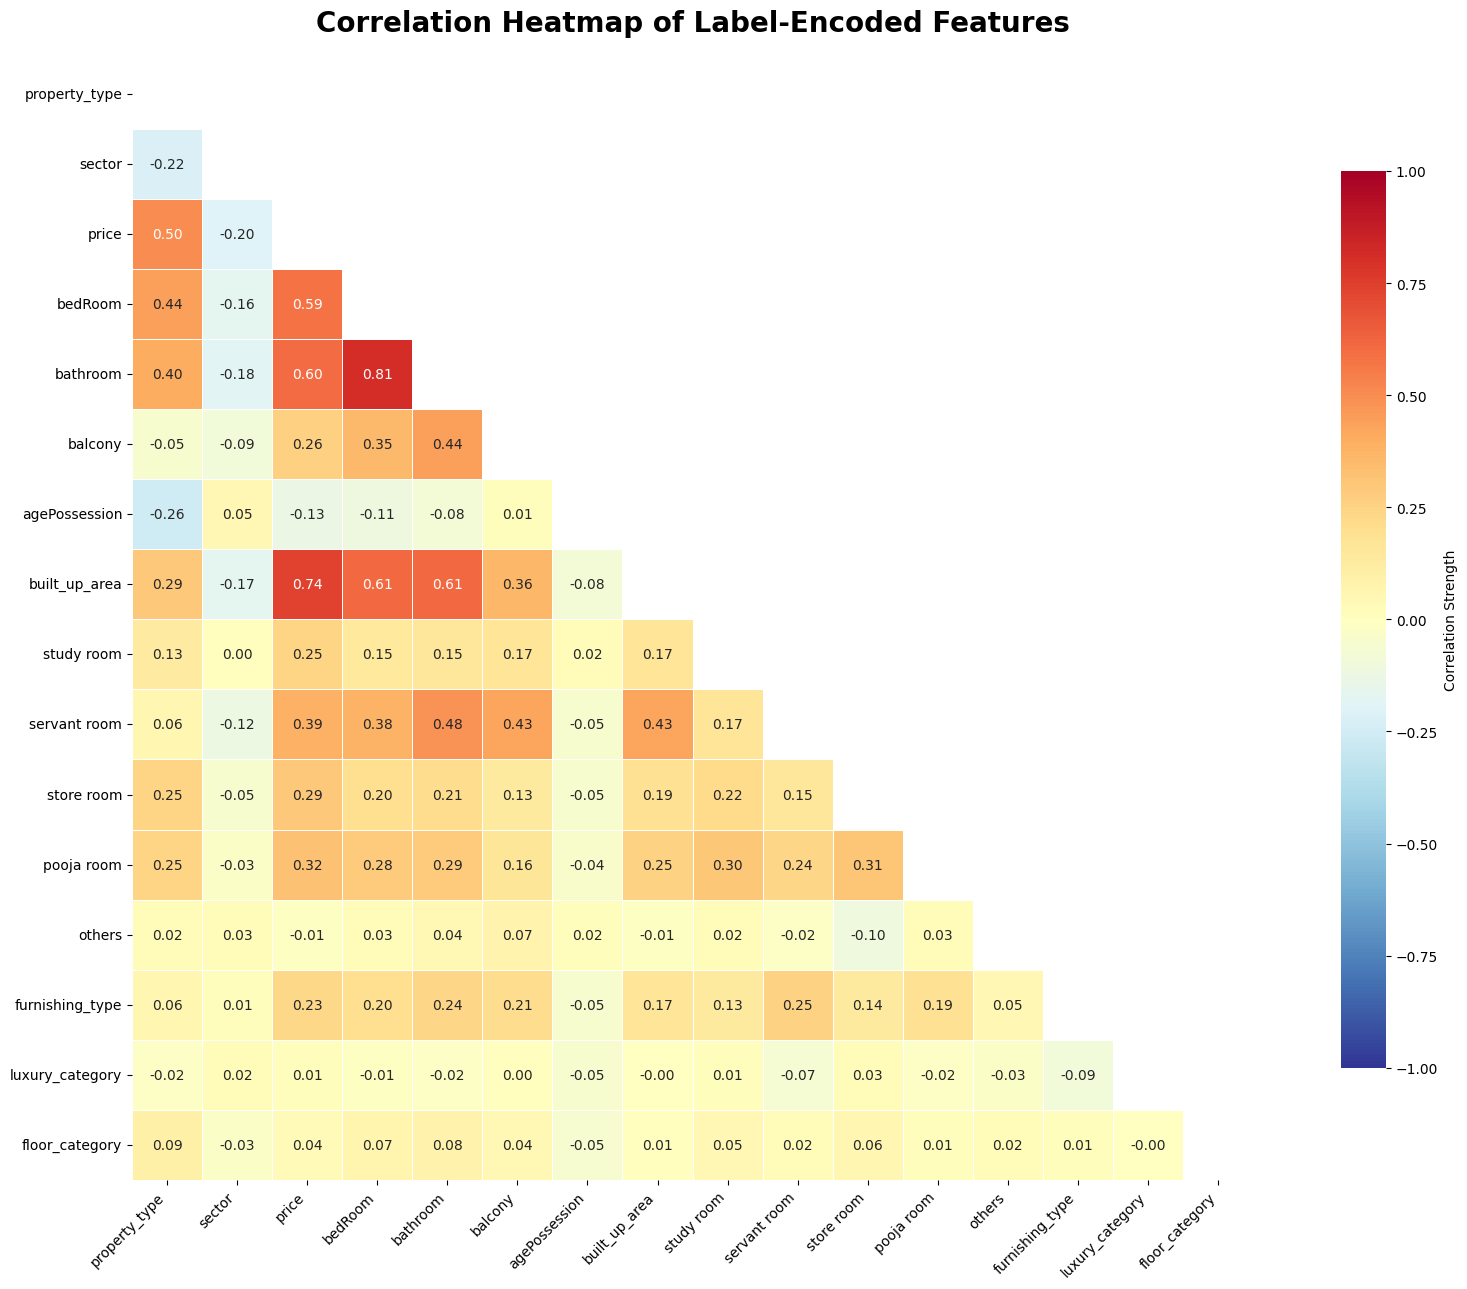

In [28]:
corr_matrix = data_label_encoded.corr()
# Hide duplicate upper-triangle values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(18, 13))
sns.heatmap(corr_matrix,mask=mask,cmap='RdYlBu_r',annot=True,fmt='.2f',vmin=-1,vmax=1,center=0,square=True,linewidths=0.7,linecolor='white',cbar_kws={'shrink': 0.8, 'label': 'Correlation Strength'})

plt.title('Correlation Heatmap of Label-Encoded Features',fontsize=20,fontweight='bold',pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

In [30]:
fi_df1 = data_label_encoded.corr()[['price']].drop('price').reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,property_type,0.503799
1,sector,-0.197774
2,bedRoom,0.585895
3,bathroom,0.603470
4,balcony,0.263466
5,agePossession,-0.132613
6,built_up_area,0.738106
7,study room,0.248358
8,servant room,0.389532
9,store room,0.293755


Technique 2 - Random Forest Feature Importance

In [31]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.643141
1,sector,0.109167
0,property_type,0.097812
3,bathroom,0.025447
2,bedRoom,0.025262
8,servant room,0.020589
5,agePossession,0.014740
4,balcony,0.014544
12,furnishing_type,0.011930
7,study room,0.008379


Technique 3 - Gradient Boosting Feature importances

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.687241
1,sector,0.103579
0,property_type,0.100063
2,bedRoom,0.032809
3,bathroom,0.030291
8,servant room,0.025306
7,study room,0.004515
5,agePossession,0.004315
9,store room,0.003255
12,furnishing_type,0.002999


Technique 4 - Permutation Importance

In [33]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.690067
0,property_type,0.158518
1,sector,0.126799
7,study room,0.008714
4,balcony,0.008393
13,luxury_category,0.008011
8,servant room,0.005733
9,store room,0.003439
3,bathroom,0.002272
11,others,0.001633


Technique 5 - LASSO

In [34]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.512753
0,property_type,0.743815
3,bathroom,0.269364
7,study room,0.190820
12,furnishing_type,0.177290
9,store room,0.171152
8,servant room,0.164372
10,pooja room,0.087540
13,luxury_category,0.063676
2,bedRoom,0.007247


Technique 6 - RFE

In [35]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.640453
1,sector,0.107968
0,property_type,0.100537
2,bedRoom,0.026859
3,bathroom,0.024368
8,servant room,0.019950
4,balcony,0.014684
5,agePossession,0.014593
12,furnishing_type,0.010516
13,luxury_category,0.008991


Technique 7 - Linear Regression Weights

In [37]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.515374
0,property_type,0.743977
3,bathroom,0.276019
7,study room,0.198794
12,furnishing_type,0.186670
9,store room,0.175620
8,servant room,0.173653
10,pooja room,0.090450
13,luxury_category,0.075264
2,bedRoom,0.009834


Technique 8 - SHAP

In [38]:
!pip install shap

In [39]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 6.75275463e-01, -1.75607252e+00, -3.22600678e-01, ...,
        -8.07712536e-02, -1.65560334e-02,  2.01154502e-02],
       [-1.72138814e-01, -1.79279828e-01, -5.81283784e-02, ...,
        -1.16337573e-02, -6.01299233e-03, -1.18634457e-02],
       [-1.77685173e-01, -3.94751075e-01, -4.46340847e-02, ...,
        -1.26625793e-02, -3.20351134e-03, -4.25219968e-03],
       ...,
       [-2.88922087e-01, -1.60044192e-01, -1.23126925e-01, ...,
        -1.32606070e-02, -9.39523511e-05, -2.16389543e-03],
       [-1.69601915e-01,  2.59615797e-01, -4.40534249e-02, ...,
         2.04022184e-01,  1.34820220e-02, -5.87313590e-03],
       [-5.31582954e-01, -4.21477811e-01, -2.37072067e-03, ...,
        -8.62605248e-03, -2.41463908e-02, -3.96938307e-02]])

In [40]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.250791
0,property_type,0.475631
1,sector,0.396118
3,bathroom,0.121626
8,servant room,0.099044
2,bedRoom,0.057101
4,balcony,0.041715
12,furnishing_type,0.031893
5,agePossession,0.026801
14,floor_category,0.025762


In [41]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [42]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.503799,0.097812,0.100063,0.158518,0.743815,0.100537,0.743977,0.475631
sector,-0.197774,0.109167,0.103579,0.126799,-0.056760,0.107968,-0.065932,0.396118
bedRoom,0.585895,0.025262,0.032809,-0.012176,0.007247,0.026859,0.009834,0.057101
bathroom,0.603470,0.025447,0.030291,0.002272,0.269364,0.024368,0.276019,0.121626
balcony,0.263466,0.014544,0.002414,0.008393,-0.052246,0.014684,-0.075187,0.041715
agePossession,-0.132613,0.014740,0.004315,-0.005601,-0.000000,0.014593,0.001965,0.026801
built_up_area,0.738106,0.643141,0.687241,0.690067,1.512753,0.640453,1.515374,1.250791
study room,0.248358,0.008379,0.004515,0.008714,0.190820,0.008459,0.198794,0.019077
servant room,0.389532,0.020589,0.025306,0.005733,0.164372,0.019950,0.173653,0.099044


In [43]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [44]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.631713
property_type,0.128762
sector,0.120606
bathroom,0.025859
servant room,0.021975
bedRoom,0.018896
balcony,0.011260
agePossession,0.007649
study room,0.007523


In [45]:
# to drop pooja room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,1,0,0,0,2.0,1.0
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,0,0,0,1.0,2.0
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,0,0,0,1.0,2.0
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,0,0,0,1,1.0,2.0
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,1,0,0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,0,0,0,1.0,2.0
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,0,0,0,1.0,0.0
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,0,0,0,2.0,2.0
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,0,1,1,2,2.0,2.0


In [46]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [47]:
scores.mean()

np.float64(0.7929200213824161)

In [53]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room','others']), y_label, cv=5, scoring='r2')

In [54]:
scores.mean()

np.float64(0.7975662263210913)

In [56]:
export_df = X_label.drop(columns=['pooja room','others'])
export_df['price'] = y_label

In [57]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [58]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,92.0,4,4,3.0,3.0,5480.0,0,1,1,0,2.0,1.0,4.35
1,0.0,9.0,2,2,2.0,3.0,543.0,0,0,0,0,1.0,2.0,0.28
2,0.0,111.0,2,2,1.0,3.0,577.0,0,0,0,0,1.0,2.0,0.29
3,0.0,55.0,3,4,3.0,3.0,2060.0,1,0,0,1,1.0,2.0,2.55
4,1.0,44.0,3,3,3.0,4.0,1570.0,0,0,0,0,2.0,2.0,1.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3682,1.0,20.0,3,3,2.0,0.0,3249.0,0,0,0,0,1.0,2.0,5.51
3683,0.0,98.0,2,2,3.0,3.0,1339.0,1,0,0,0,1.0,0.0,1.23
3684,0.0,43.0,2,3,4.0,3.0,1300.0,1,0,0,0,2.0,2.0,0.87
3685,0.0,27.0,2,2,2.0,3.0,1200.0,0,0,0,2,2.0,2.0,1.65
